Querying the wales lidar tiles is actually far more straightforward and faster than the process required for England.


In [26]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

# for dev work

import sys
import importlib
import matplotlib.pyplot as plt
import json
import matplotlib.cm as cm
import matplotlib
import numpy as np
import matplotlib.colors as mcolors

import folium
from folium import plugins
import json

from rasterio.mask import mask
from shapely.geometry import mapping

# Add src to path (do this once at the top)
sys.path.insert(0, '../../src')

# Initial import
import park_vga

# After editing:
importlib.reload(park_vga.defining_grids)
importlib.reload(park_vga.lidar)
importlib.reload(park_vga)

<module 'park_vga' from '/Users/maeve/Documents/park-vga/notebooks/wales_lidar_processing/../../src/park_vga/__init__.py'>

In [27]:
boundaries_file = "../../example_datasets/Blaenau Gwent_pp_or_g_cmb.geojson"
primary_name = "Bedwellty House & Park"

buffer_distance = 20 # metres

In [28]:
lidar_dtm  = "/Volumes/Extreme SSD/wales_lidar/wales_dtm_32bit_cog.tif"
lidar_dsm  = "/Volumes/Extreme SSD/wales_lidar/wales_dsm_32bit_cog.tif"

In [29]:
park_gdf = park_vga.load_data(boundaries_file, primary_name, buffer_distance)

In [30]:
with rasterio.open(lidar_dtm) as src:
    print("Raster CRS:", src.crs)
    print("Raster bounds:", src.bounds)
    print("Raster shape:", src.shape)
    print("Raster nodata value:", src.nodata)
    # Check if there's actual data
    data_sample = src.read(1, window=rasterio.windows.Window(0, 0, 100, 100))
    print("Sample data range:", data_sample.min(), "to", data_sample.max())

# Check park geometry
print("\nPark CRS:", park_gdf.crs)
print("Park bounds:", park_gdf.bounds.iloc[0])

Raster CRS: EPSG:27700
Raster bounds: BoundingBox(left=164993.0, bottom=164000.0, right=356000.0, top=397000.0)
Raster shape: (233000, 191007)
Raster nodata value: -9999.0
Sample data range: -9999.0 to -9999.0

Park CRS: EPSG:27700
Park bounds: minx    314027.486960
miny    208321.375793
maxx    314452.031876
maxy    208766.223838
Name: 13, dtype: float64


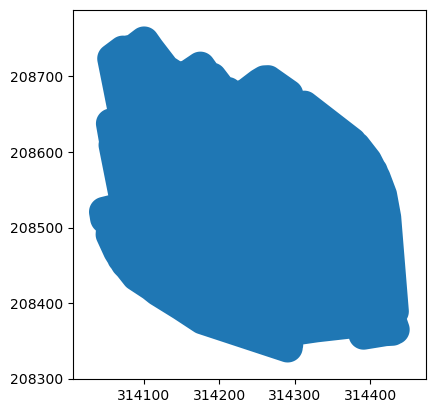

In [31]:
park_vga.check_plot(park_gdf)

In [32]:
# def extract_park_raster_wales(park_gdf, dtm_path, dsm_path):
#     """
#     Extract DTM and DSM data for a park from Wales COG rasters using bounding box.
    
#     Simpler alternative to load_lidar_rasters_for_park() optimized for single-file 
#     COG datasets (Wales) rather than tiled datasets (England).
    
#     Parameters:
#     -----------
#     park_gdf : GeoDataFrame
#         Park boundary geometry
#     dtm_path : str
#         Path to DTM raster file
#     dsm_path : str
#         Path to DSM raster file
    
#     Returns:
#     --------
#     dict with keys:
#         - 'dsm': DSM clipped array
#         - 'dtm': DTM clipped array  
#         - 'height_above_ground': DSM - DTM (vegetation/building height)
#         - 'dsm_meta': DSM metadata
#         - 'dtm_meta': DTM metadata
#         - 'transform': rasterio Affine transform for clipped data
#         - 'crs': Coordinate reference system
    
#     or None if error
#     """
#     from rasterio.windows import from_bounds
    
#     try:
#         # Open DTM to get CRS
#         with rasterio.open(dtm_path) as src:
#             raster_crs = src.crs
        
#         # Ensure park is in raster CRS
#         if park_gdf.crs != raster_crs:
#             print(f"Reprojecting park from {park_gdf.crs} to {raster_crs}")
#             park_gdf = park_gdf.to_crs(raster_crs)
        
#         minx, miny, maxx, maxy = park_gdf.bounds.iloc[0]
        
#         # Extract DTM
#         with rasterio.open(dtm_path) as src:
#             window = from_bounds(minx, miny, maxx, maxy, src.transform)
#             dtm_clipped = src.read(1, window=window)
#             dtm_transform = src.window_transform(window)
#             dtm_meta = src.meta.copy()
#             dtm_meta.update({
#                 'height': dtm_clipped.shape[0],
#                 'width': dtm_clipped.shape[1],
#                 'transform': dtm_transform
#             })
        
#         # Extract DSM
#         with rasterio.open(dsm_path) as src:
#             window = from_bounds(minx, miny, maxx, maxy, src.transform)
#             dsm_clipped = src.read(1, window=window)
#             dsm_transform = src.window_transform(window)
#             dsm_meta = src.meta.copy()
#             dsm_meta.update({
#                 'height': dsm_clipped.shape[0],
#                 'width': dsm_clipped.shape[1],
#                 'transform': dsm_transform
#             })
        
#         # Calculate height above ground
#         height_above_ground = dsm_clipped - dtm_clipped
        
#         # Report statistics
#         valid_pixels = np.sum(~np.isnan(height_above_ground))
#         if valid_pixels > 0:
#             height_range = f"{np.nanmin(height_above_ground):.1f}m to {np.nanmax(height_above_ground):.1f}m"
#         else:
#             height_range = "No valid data"
        
#         print(f"Extracted {dsm_clipped.shape} pixels, Height range: {height_range}")
        
#         return {
#             'dsm': dsm_clipped,
#             'dtm': dtm_clipped,
#             'height_above_ground': height_above_ground,
#             'dsm_meta': dsm_meta,
#             'dtm_meta': dtm_meta,
#             'transform': dtm_transform,
#             'crs': raster_crs
#         }
    
#     except Exception as e:
#         print(f"ERROR extracting park raster: {e}")
#         return None

In [33]:
lidar_data = park_vga.extract_park_raster_wales(park_gdf, lidar_dtm, lidar_dsm)


Extracted (445, 425) pixels, Height range: -0.6m to 30.8m


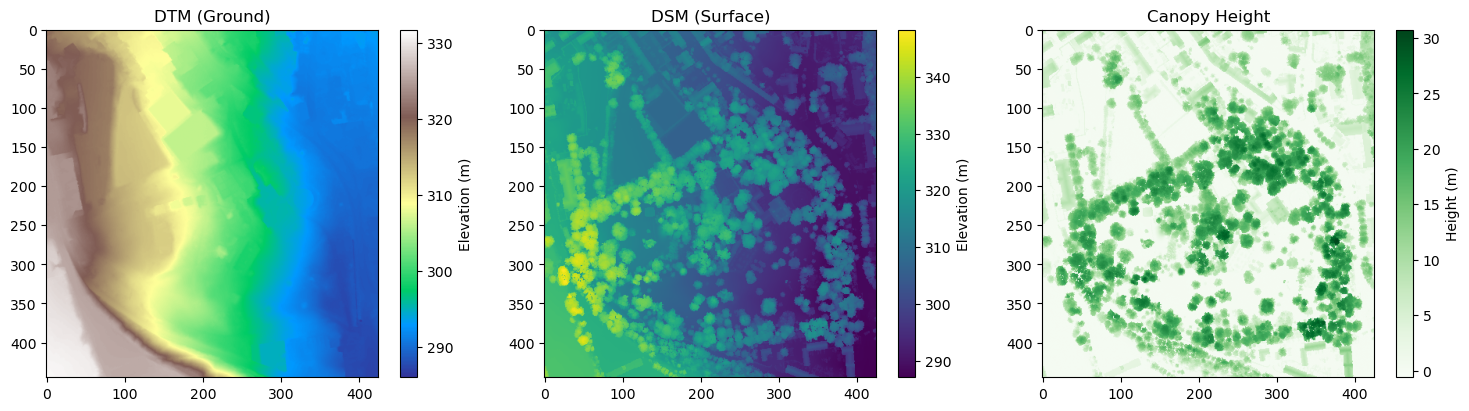

In [34]:
dtm = lidar_data['dtm']
dsm = lidar_data['dsm']
height = lidar_data['height_above_ground']
transform = lidar_data['transform']

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

g = axes[0].imshow(dtm, cmap='terrain')
axes[0].set_title('DTM (Ground)')
fig.colorbar(g, label='Elevation (m)')

h = axes[1].imshow(dsm, cmap='viridis')
axes[1].set_title('DSM (Surface)')
fig.colorbar(h, label='Elevation (m)')

i = axes[2].imshow(height, cmap='Greens')
axes[2].set_title('Canopy Height')
fig.colorbar(i, label='Height (m)')

plt.tight_layout()
plt.show()

In [35]:
hex_grid = park_vga.create_hexagon_grid(park_gdf, spacing=10, return_mode='both')

Created 1234 pointy-top hexagons (10m vertical spacing)


In [36]:
visibility_results = park_vga.calculate_visibility_metrics(
    hex_grid["centroids"], 
    lidar_data['dsm'], 
    lidar_data['dtm'], 
    lidar_data['transform'],
    observer_height=1.0,
    target_height=0,
    max_distance=100
)

Calculating visibility for 1234 points
Processing point 1/1234
Processing point 51/1234
Processing point 101/1234
Processing point 151/1234
Processing point 201/1234
Processing point 251/1234
Processing point 301/1234
Processing point 351/1234
Processing point 401/1234
Processing point 451/1234
Processing point 501/1234
Processing point 551/1234
Processing point 601/1234
Processing point 651/1234
Processing point 701/1234
Processing point 751/1234
Processing point 801/1234
Processing point 851/1234
Processing point 901/1234
Processing point 951/1234
Processing point 1001/1234
Processing point 1051/1234
Processing point 1101/1234
Processing point 1151/1234
Processing point 1201/1234


In [37]:
visibility_results = visibility_results.set_geometry(hex_grid["polygons"].geometry)

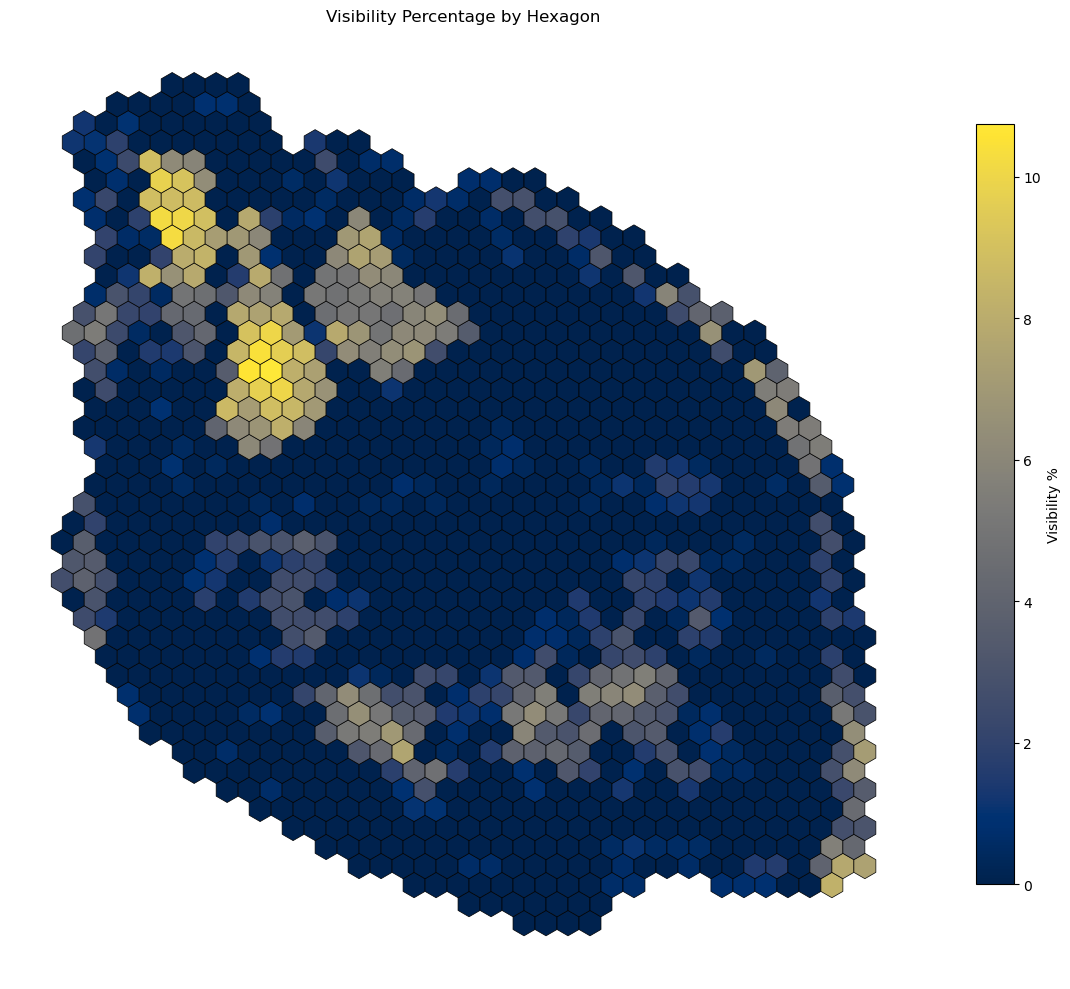

In [38]:
fig, ax = plt.subplots(figsize=(12, 10))
visibility_results.plot(column='visibility_pct', 
                          cmap='cividis', 
                          ax=ax,
                          legend=True,
                          edgecolor='k',
                          linewidth=0.5,
                          legend_kwds={'label': 'Visibility %', 'shrink': 0.8})
ax.set_title('Visibility Percentage by Hexagon')
ax.axis('off')
plt.tight_layout()
plt.show()

In [39]:
# Keep hexagons that intersect (touch or overlap) the park boundary
park_original =  park_vga.load_data(boundaries_file, primary_name, 0)
park_boundary = park_original.geometry.iloc[0]

visibility_clipped = visibility_results[visibility_results.geometry.intersects(park_boundary)]

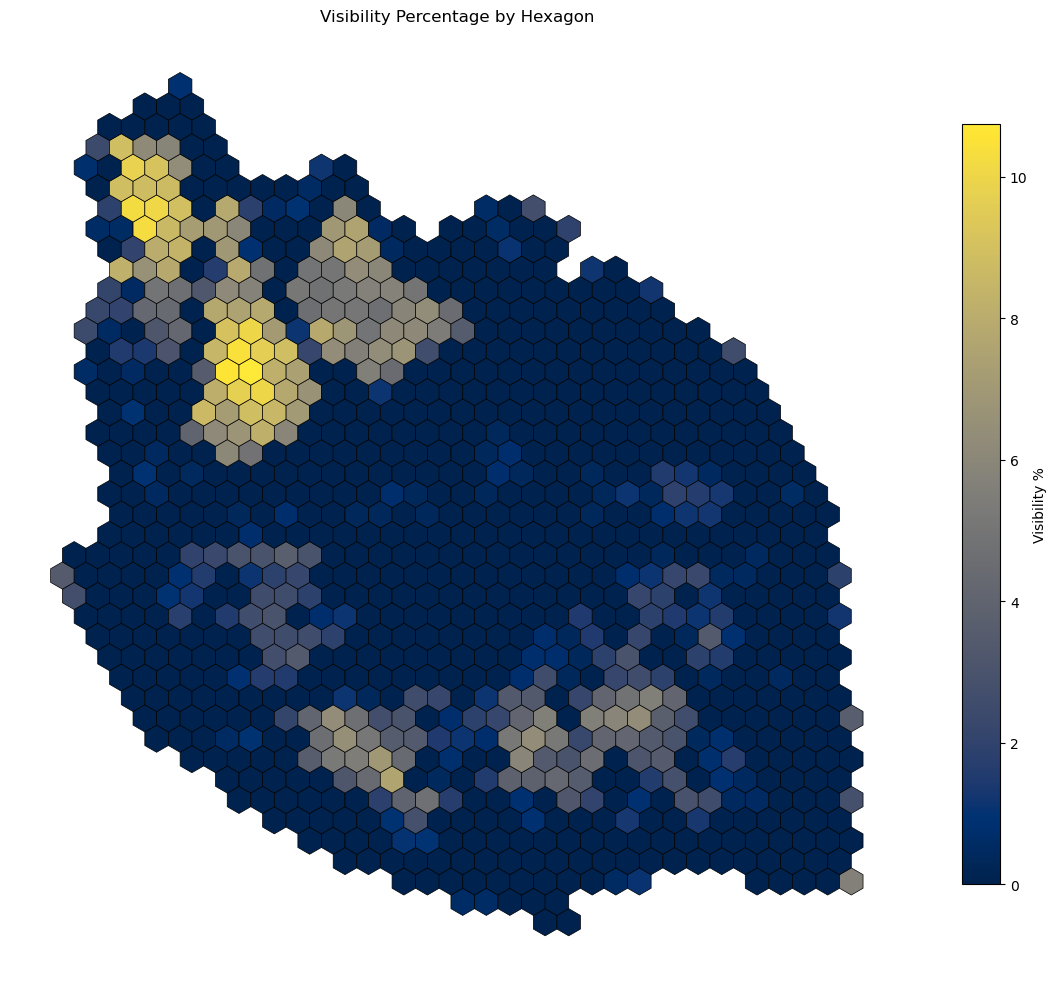

In [40]:
fig, ax = plt.subplots(figsize=(12, 10))
visibility_clipped.plot(column='visibility_pct', 
                          cmap='cividis', 
                          ax=ax,
                          legend=True,
                          edgecolor='k',
                          linewidth=0.5,
                          legend_kwds={'label': 'Visibility %', 'shrink': 0.8})
ax.set_title('Visibility Percentage by Hexagon')
ax.axis('off')
plt.tight_layout()
plt.show()

In [41]:
hex_polygons = list(zip(
    hex_grid['centroids'].geometry,
    hex_grid['polygons'].geometry
))

In [42]:
foliage_stats = park_vga.extract_foliage_by_hexgrid(
    height_raster=lidar_data['height_above_ground'],
    transform=lidar_data['transform'],
    hex_polygons=hex_polygons,
    min_height=2.0,
    crs='EPSG:27700'
)

Extracting foliage data from 1234 hexagons...
  Processed 123 / 1234 hexagons
  Processed 246 / 1234 hexagons
  Processed 369 / 1234 hexagons
  Processed 492 / 1234 hexagons
  Processed 615 / 1234 hexagons
  Processed 738 / 1234 hexagons
  Processed 861 / 1234 hexagons
  Processed 984 / 1234 hexagons
  Processed 1107 / 1234 hexagons
  Processed 1230 / 1234 hexagons


In [43]:
foliage_stats = foliage_stats.set_geometry(hex_grid["polygons"].geometry)


In [44]:
# Keep hexagons that intersect (touch or overlap) the park boundary -5 (removing nearby buildings)
park_original =  park_vga.load_data(boundaries_file, primary_name, -5)
park_boundary = park_original.geometry.iloc[0]

foliage_clipped = foliage_stats[foliage_stats.geometry.intersects(park_boundary)]

In [46]:
# Reproject to WGS84
foliage_wgs84 = foliage_clipped.to_crs('EPSG:4326')

# Create map centered on the park
center_lat = foliage_wgs84.geometry.centroid.y.mean()
center_lon = foliage_wgs84.geometry.centroid.x.mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=14,
    tiles='CartoDB positron'
)

# Define the three columns and their properties
layers_config = [
    {'column': 'low_level_<0.5', 'name': 'Low Level (<0.5m)', 'show': True},
    {'column': 'mid_level_0.5-2', 'name': 'Mid Level (0.5-2m)', 'show': True},
    {'column': 'tall_2+', 'name': 'Tall (2m+)', 'show': True},
]

# Create color mapping function with vmin=10
cmap = cm.get_cmap('cividis')

def get_color(value, vmin=10, vmax=100):
    if value < vmin:
        return None  # No color for values below vmin
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    return mcolors.to_hex(cmap(norm(value)))

# Create a layer for each column
for layer_config in layers_config:
    column = layer_config['column']
    layer_name = layer_config['name']
    
    # Convert to GeoJSON
    geojson_data = json.loads(foliage_wgs84.to_json())
    
    # Create a FeatureGroup for this layer
    fg = folium.FeatureGroup(name=layer_name, show=layer_config['show'])
    
    # Add each feature with appropriate styling
    for feature in geojson_data['features']:
        props = feature['properties']
        value = props.get(column)
        
        if value is not None and value >= 10:
            color = get_color(value)
            folium.GeoJson(
                data=feature,
                style_function=lambda x, col=color: {
                    'fillColor': col,
                    'color': 'black',
                    'weight': 0.5,
                    'fillOpacity': 0.7
                }
            ).add_to(fg)
    
    fg.add_to(m)

# Add layer control to toggle layers on/off
folium.LayerControl().add_to(m)

m.show_in_browser()

/var/folders/3s/z86xkbn12m94tfxyzcgrwf080000gn/T/ipykernel_30625/3298525412.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lat = foliage_wgs84.geometry.centroid.y.mean()
/var/folders/3s/z86xkbn12m94tfxyzcgrwf080000gn/T/ipykernel_30625/3298525412.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lon = foliage_wgs84.geometry.centroid.x.mean()
/var/folders/3s/z86xkbn12m94tfxyzcgrwf080000gn/T/ipykernel_30625/3298525412.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('cividis')
765:773: executio

Your map should have been opened in your browser automatically.
Press ctrl+c to return.
